# 04 Pathway Enrichment Analysis

This notebook performs pathway-level interpretation of macrophage disease-associated gene expression changes in inflammatory bowel disease.

The goal is to move from individual differentially expressed genes to broader biological programs associated with inflamed intestinal tissue.

## 1. Setup

Import libraries for data handling and pathway enrichment analysis.

In [5]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import gseapy as gp

## 2. Load Macrophage Differential Expression Results

Load the macrophage inflamed-versus-healthy differential expression table generated in the disease-associated expression notebook.

In [2]:
de_path = Path("../results/tables/macrophage_inflamed_vs_healthy_significant_genes.csv")

macrophage_de = pd.read_csv(de_path)

macrophage_de.head()

,names,scores,logfoldchanges,pvals,pvals_adj
0,MALAT1,45.838917,2.860634,0.0,0.0
1,S100A6,44.159744,2.691585,0.0,0.0
2,RPL39,43.613240,2.256023,0.0,0.0
3,NEAT1,40.950940,2.325158,0.0,0.0
4,S100A9,39.425312,4.165968,0.0,0.0


## 3. Extract Upregulated Genes In Inflamed Macrophages

Genes with positive log-fold-change are more highly expressed in inflamed macrophages compared with healthy macrophages. These genes are used for pathway enrichment analysis.

In [3]:
upregulated_genes = (
    macrophage_de[macrophage_de["logfoldchanges"] > 0]
    .sort_values("logfoldchanges", ascending=False)["names"]
    .dropna()
    .unique()
    .tolist()
)

len(upregulated_genes), upregulated_genes[:20]

(245,
 ['AQP9',
  'RNU5D-1',
  'S100A12',
  'RNVU1-13',
  'S100A8',
  'RETN',
  'FCN1',
  'VCAN',
  'NRGN',
  'RNVU1-19',
  'C11orf21',
  'RNVU1-14',
  'CDA',
  'RAB3D',
  'FAM65B',
  'SLC11A1',
  'SLC16A10',
  'SPINK4',
  'RP11-386I14.4',
  'RNASE2'])

## 4. Run Gene Ontology Enrichment Analysis

Gene Ontology Biological Process enrichment is used to identify biological programs over-represented among genes upregulated in inflamed macrophages.

In [7]:
enrichment_results = gp.enrichr(
    gene_list=upregulated_genes,
    gene_sets="GO_Biological_Process_2023",
    organism="human",
    outdir=None,
    cutoff=0.05
)

go_results = enrichment_results.results

go_results.head()

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,GO_Biological_Process_2023,Cytoplasmic Translation (GO:0002181),14/93,7.421930e-12,1.485870e-08,0,0,15.094745,386.826718,RPL32;RPL21;RPL34;EIF3M;RPS15A;RPS27;RPS29;RPL...
1,GO_Biological_Process_2023,Defense Response To Fungus (GO:0050832),8/29,1.554568e-09,1.556123e-06,0,0,31.720313,643.353559,CX3CR1;CLEC4A;CLEC7A;S100A12;NRG1;CLEC4E;S100A...
2,GO_Biological_Process_2023,Gene Expression (GO:0010467),19/296,4.759201e-09,3.175974e-06,0,0,5.911664,113.286320,NUP214;DDX17;RPL32;RPL21;RPL34;TESC;HNRNPU;RPS...
3,GO_Biological_Process_2023,Macromolecule Biosynthetic Process (GO:0009059),15/183,8.072595e-09,4.040334e-06,0,0,7.603649,141.692410,RPL32;RPL21;RPL34;SLC11A1;RPS27;RPS15A;RPS29;E...
4,GO_Biological_Process_2023,Cellular Response To Cytokine Stimulus (GO:007...,18/308,5.174995e-08,2.072068e-05,0,0,5.322345,89.292150,IFITM2;CSF3R;DUSP1;LRRK2;HNRNPU;IRAK3;LILRB2;L...


## 5. Inspect Top Enriched Biological Processes

The top enriched Gene Ontology terms are ranked by adjusted p-value to identify the strongest biological programs associated with genes upregulated in inflamed macrophages.

This first enrichment result is inspected before additional filtering so that broad technical or housekeeping signals can be identified and interpreted cautiously.

In [8]:
top_go_results = (
    go_results
    .sort_values("Adjusted P-value")
    .head(15)
)

top_go_results[["Term", "Adjusted P-value", "Odds Ratio", "Combined Score", "Genes"]]

,Term,Adjusted P-value,Odds Ratio,Combined Score,Genes
0,Cytoplasmic Translation (GO:0002181),1.485870e-08,15.094745,386.826718,RPL32;RPL21;RPL34;EIF3M;RPS15A;RPS27;RPS29;RPL...
1,Defense Response To Fungus (GO:0050832),1.556123e-06,31.720313,643.353559,CX3CR1;CLEC4A;CLEC7A;S100A12;NRG1;CLEC4E;S100A...
2,Gene Expression (GO:0010467),3.175974e-06,5.911664,113.286320,NUP214;DDX17;RPL32;RPL21;RPL34;TESC;HNRNPU;RPS...
3,Macromolecule Biosynthetic Process (GO:0009059),4.040334e-06,7.603649,141.692410,RPL32;RPL21;RPL34;SLC11A1;RPS27;RPS15A;RPS29;E...
4,Cellular Response To Cytokine Stimulus (GO:007...,2.072068e-05,5.322345,89.292150,IFITM2;CSF3R;DUSP1;LRRK2;HNRNPU;IRAK3;LILRB2;L...
5,Peptide Biosynthetic Process (GO:0043043),2.607599e-05,7.578181,124.014184,RPL32;RPL21;RPL34;RPS27;RPS15A;RPS29;RPL36;RPL...
6,Translation (GO:0006412),3.387038e-04,5.381543,73.203994,RPL32;RPL21;RPL34;RPS27;RPS15A;RPS29;EEF1D;RPL...
7,B Cell Receptor Signaling Pathway (GO:0050853),3.387038e-04,14.868778,200.919495,IGHG3;IGHG1;MEF2C;IGHG2;PTPRC;PRKCB;MNDA
8,Positive Regulation Of Cytokine Production (GO...,5.085404e-04,4.470467,58.065296,FCN1;CEBPB;TRAF3IP3;TGFB1;SLC11A1;LILRB2;LILRA...
9,Mesenchymal Cell Differentiation (GO:0048762),7.653161e-04,12.332916,152.922707,DDX17;MEF2C;DDX5;TGFB1;CTNNB1;S100A4;HIF1A


## 6. Filter Broad Technical Or Housekeeping Genes

The initial enrichment results are partly dominated by broad translation and gene expression terms, driven mainly by ribosomal genes such as `RPL` and `RPS` genes. These signals may reflect increased protein synthesis or general cell activation, but they are not specific enough to support a focused inflammatory macrophage interpretation.

To prioritize immune-relevant pathways, ribosomal genes, mitochondrial genes, and broad non-coding RNA genes are removed before repeating enrichment analysis.

In [9]:
excluded_prefixes = ("RPL", "RPS", "MT-")
excluded_genes = {"MALAT1", "NEAT1"}

filtered_upregulated_genes = [
    gene for gene in upregulated_genes
    if not gene.startswith(excluded_prefixes)
    and gene not in excluded_genes
]

print("Original upregulated gene count:", len(upregulated_genes))
print("Filtered upregulated gene count:", len(filtered_upregulated_genes))

filtered_upregulated_genes[:25]

Original upregulated gene count: 245
Filtered upregulated gene count: 218


['AQP9',
 'RNU5D-1',
 'S100A12',
 'RNVU1-13',
 'S100A8',
 'RETN',
 'FCN1',
 'VCAN',
 'NRGN',
 'RNVU1-19',
 'C11orf21',
 'RNVU1-14',
 'CDA',
 'RAB3D',
 'FAM65B',
 'SLC11A1',
 'SLC16A10',
 'SPINK4',
 'RP11-386I14.4',
 'RNASE2',
 'MGST1',
 'S100A9',
 'MTMR11',
 'CD300E',
 'SNORD3D']

## 7. Repeat Enrichment Analysis With Filtered Gene List

Gene Ontology enrichment is repeated using the filtered inflamed macrophage gene list. This second enrichment analysis is used for biological interpretation because it reduces broad housekeeping signals and prioritizes immune, inflammatory, and macrophage-relevant processes.

In [10]:
filtered_enrichment_results = gp.enrichr(
    gene_list=filtered_upregulated_genes,
    gene_sets="GO_Biological_Process_2023",
    organism="human",
    outdir=None,
    cutoff=0.05
)

filtered_go_results = filtered_enrichment_results.results

filtered_go_results.head()

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,GO_Biological_Process_2023,Defense Response To Fungus (GO:0050832),8/29,6.175559e-10,0.000001,0,0,35.847619,760.157776,CX3CR1;CLEC4A;CLEC7A;S100A12;NRG1;CLEC4E;S100A...
1,GO_Biological_Process_2023,Cellular Response To Cytokine Stimulus (GO:007...,18/308,8.475109e-09,0.000008,0,0,6.049241,112.432000,IFITM2;CSF3R;DUSP1;LRRK2;HNRNPU;IRAK3;LILRB2;L...
2,GO_Biological_Process_2023,Positive Regulation Of Cytokine Production (GO...,16/320,4.883798e-07,0.000307,0,0,5.075039,73.751343,FCN1;CEBPB;TRAF3IP3;TGFB1;SLC11A1;LILRB2;LILRA...
3,GO_Biological_Process_2023,B Cell Receptor Signaling Pathway (GO:0050853),7/46,6.192689e-07,0.000307,0,0,16.794386,240.071147,IGHG3;IGHG1;MEF2C;IGHG2;PTPRC;PRKCB;MNDA
4,GO_Biological_Process_2023,Hemopoiesis (GO:0030097),9/101,1.614130e-06,0.000630,0,0,9.216247,122.914454,NOTCH2;CEBPB;TGFB1;PTPRC;TET2;IL7R;EVI2B;ZFP36...


## 8. Inspect Filtered Enriched Biological Processes

The filtered enrichment results are ranked by adjusted p-value. These terms are used to identify biological processes most strongly associated with genes upregulated in inflamed macrophages.

In [11]:
filtered_top_go_results = (
    filtered_go_results
    .sort_values("Adjusted P-value")
    .head(15)
)

filtered_top_go_results[
    ["Term", "Adjusted P-value", "Odds Ratio", "Combined Score", "Genes"]
]

,Term,Adjusted P-value,Odds Ratio,Combined Score,Genes
0,Defense Response To Fungus (GO:0050832),0.000001,35.847619,760.157776,CX3CR1;CLEC4A;CLEC7A;S100A12;NRG1;CLEC4E;S100A...
1,Cellular Response To Cytokine Stimulus (GO:007...,0.000008,6.049241,112.432000,IFITM2;CSF3R;DUSP1;LRRK2;HNRNPU;IRAK3;LILRB2;L...
2,Positive Regulation Of Cytokine Production (GO...,0.000307,5.075039,73.751343,FCN1;CEBPB;TRAF3IP3;TGFB1;SLC11A1;LILRB2;LILRA...
3,B Cell Receptor Signaling Pathway (GO:0050853),0.000307,16.794386,240.071147,IGHG3;IGHG1;MEF2C;IGHG2;PTPRC;PRKCB;MNDA
4,Hemopoiesis (GO:0030097),0.000630,9.216247,122.914454,NOTCH2;CEBPB;TGFB1;PTPRC;TET2;IL7R;EVI2B;ZFP36...
5,Mesenchymal Cell Differentiation (GO:0048762),0.000630,13.930120,183.487677,DDX17;MEF2C;DDX5;TGFB1;CTNNB1;S100A4;HIF1A
6,Positive Regulation Of Intracellular Signal Tr...,0.001487,3.637198,44.223474,CX3CR1;TGFB1;PRKCB;IQGAP1;THBS1;FKBP1A;FGR;PTP...
7,Positive Regulation Of Response To External St...,0.001916,6.510942,76.425293,LGALS2;TGFB1;S100A12;ADAM8;NRG1;LCP1;S100A9;TH...
8,Regulation Of Tumor Necrosis Factor Production...,0.001916,7.176060,82.112054,CLEC4A;CX3CR1;PTPRC;CLEC7A;IRAK3;PTPN6;LCP1;LI...
9,Inflammatory Response (GO:0006954),0.001916,5.086165,57.857928,CEBPB;TGFB1;SLC11A1;FPR1;CYBB;ADAM8;FOS;LYZ;S1...


## 9. Filtered Enrichment Interpretation

After removing broad ribosomal, mitochondrial, and non-coding RNA signals, the enriched Gene Ontology terms are more directly related to immune activation and inflammation.

The filtered enrichment results show significant enrichment for `Cellular Response To Cytokine Stimulus`, `Positive Regulation Of Cytokine Production`, `Regulation Of Tumor Necrosis Factor Production`, and `Inflammatory Response`. These terms support the interpretation that macrophages from inflamed intestinal tissue show transcriptional programs associated with cytokine responsiveness and inflammatory immune activation.

The enrichment of `Defense Response To Fungus` is driven by innate immune genes such as C-type lectin receptors and inflammatory myeloid genes, which may reflect broader antimicrobial and pattern-recognition programs in inflamed intestinal macrophages rather than a fungus-specific disease process.

Together, these results strengthen the macrophage-level differential expression findings by showing that inflamed macrophage upregulated genes converge on inflammatory and innate immune biological processes.

## 10. Visualize Top Enriched Biological Processes

The top filtered Gene Ontology terms are visualized using adjusted p-value significance. Larger bars indicate stronger statistical enrichment.

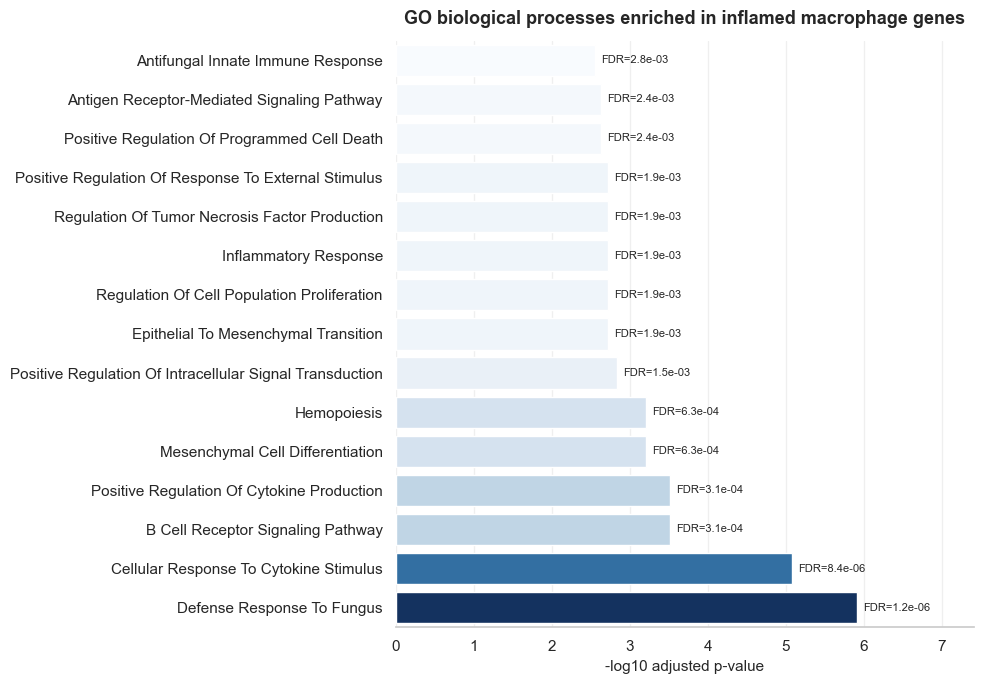

In [14]:
plot_go = filtered_top_go_results.copy()

plot_go["neg_log10_adj_p"] = -np.log10(plot_go["Adjusted P-value"])

plot_go["Term_clean"] = (
    plot_go["Term"]
    .str.replace(r"\s*\(GO:\d+\)", "", regex=True)
)

plot_go = plot_go.sort_values("neg_log10_adj_p", ascending=True)

sns.set_theme(style="whitegrid", context="notebook")

plt.figure(figsize=(10, 7))

ax = sns.barplot(
    data=plot_go,
    x="neg_log10_adj_p",
    y="Term_clean",
    hue="neg_log10_adj_p",
    palette="Blues",
    dodge=False,
    legend=False
)

for i, (_, row) in enumerate(plot_go.iterrows()):
    ax.text(
        row["neg_log10_adj_p"] + 0.08,
        i,
        f"FDR={row['Adjusted P-value']:.1e}",
        va="center",
        fontsize=8
    )

ax.set_xlabel("-log10 adjusted p-value", fontsize=11)
ax.set_ylabel("")
ax.set_title(
    "GO biological processes enriched in inflamed macrophage genes",
    fontsize=13,
    weight="bold",
    pad=12
)

ax.grid(axis="x", alpha=0.3)
ax.grid(axis="y", visible=False)

sns.despine(left=True, bottom=False)

plt.xlim(0, plot_go["neg_log10_adj_p"].max() + 1.5)

plt.tight_layout()
plt.savefig(
    "../results/figures/macrophage_go_enrichment_filtered.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 11. Save Pathway Enrichment Results

The unfiltered and filtered Gene Ontology enrichment results are saved as project outputs. The filtered results are used for the primary biological interpretation because broad ribosomal, mitochondrial, and non-coding RNA signals were removed before enrichment.

In [15]:
go_results_path = "../results/tables/macrophage_go_enrichment_unfiltered.csv"
filtered_go_results_path = "../results/tables/macrophage_go_enrichment_filtered.csv"

go_results.to_csv(go_results_path, index=False)
filtered_go_results.to_csv(filtered_go_results_path, index=False)

go_results_path, filtered_go_results_path

('../results/tables/macrophage_go_enrichment_unfiltered.csv',
 '../results/tables/macrophage_go_enrichment_filtered.csv')

## Final Biological Interpretation

Pathway enrichment analysis supports the interpretation that inflamed macrophages in IBD-associated intestinal tissue show inflammatory and innate immune activation programs.

After filtering broad housekeeping signals, the strongest enriched terms included `Cellular Response To Cytokine Stimulus`, `Positive Regulation Of Cytokine Production`, `Regulation Of Tumor Necrosis Factor Production`, and `Inflammatory Response`. These terms are consistent with macrophages responding to inflammatory cytokine environments and contributing to local immune activation in inflamed tissue.

The enrichment of `Defense Response To Fungus` and related antimicrobial response terms should be interpreted as a broader innate immune pattern rather than direct evidence of fungal infection. This term is likely driven by pattern-recognition and inflammatory myeloid genes, including genes such as `S100A8`, `S100A9`, and C-type lectin receptor-associated genes.

Together, the differential expression and pathway enrichment results suggest that macrophages in inflamed IBD tissue adopt a transcriptional program consistent with inflammatory cytokine response, innate immune activation, and antimicrobial defense.

## Notebook Summary

This notebook performed Gene Ontology enrichment analysis on genes upregulated in inflamed macrophages compared with healthy macrophages.

The first enrichment analysis revealed both immune-related terms and broad protein synthesis/gene expression terms. To improve biological specificity, ribosomal genes, mitochondrial genes, and broad non-coding RNA genes were removed before repeating enrichment analysis.

The filtered enrichment results highlighted cytokine response, cytokine production, tumor necrosis factor regulation, inflammatory response, and innate immune defense processes. These pathway-level results strengthen the macrophage differential expression analysis and support the presence of inflammatory macrophage programs in IBD-associated tissue.